# **Actividad: DASHBoards y plotly**

Eugenio Sánchez Velázquez-A00573129

**Link del dataset**: https://www.kaggle.com/datasets/navjotkaushal/coffee-sales-dataset

**Justificación del dataset**: Fue seleccionado este dataset debido a que primero que todo su información está y alimpia y fácilde manejar. Había iniciado con un dataset de mental_health, pero al tratar de graficarlo la información era muy confusa y gráficamente decía mucho y nada. Así que este dataset de coffee muestra mejor la información, sus datos están más estrucurados y admás también está interesante cómo se mueve el consumo de café. Se pueden sacar varios insights de las ventas de la cafetería a través de la visualización.

## **Lectura de archivos y análisis de paletas de colores de plotly**

In [ ]:
import pandas as pd
import numpy as np
import plotly

import plotly.express as px # graficas principales
import plotly.figure_factory as ff # generar tipos especificos de figuras
import plotly.graph_objects as go # manipular elementos individuales


df=pd.read_csv('Coffe_sales.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


**Paleta de colores seleccionada LOGO: Instagram**

* Paleta de logo: '#F207B2', '#F8F3F2', '#FBAD06', '#FA5014', **'#FA0D5C'**, '#940CF5'
* Paleta de colores complementarios: #FA0D5C, #0dfaab
* Paleta de colores monocromático: #7b0002, #9e011e, #c20436, #e70a4f, #fd396a, #ff6588, #ff87a7, #ffa6c7
* Paleta de colores complementarios divididos: #7b0002, #647b00, #00337b
* Paleta de colores análogos: #fa0d5c, #fa340d, #fa0dd2
* Paleta de colores tríada: #fa0d5c, #5cfa0d, #0d5cfa


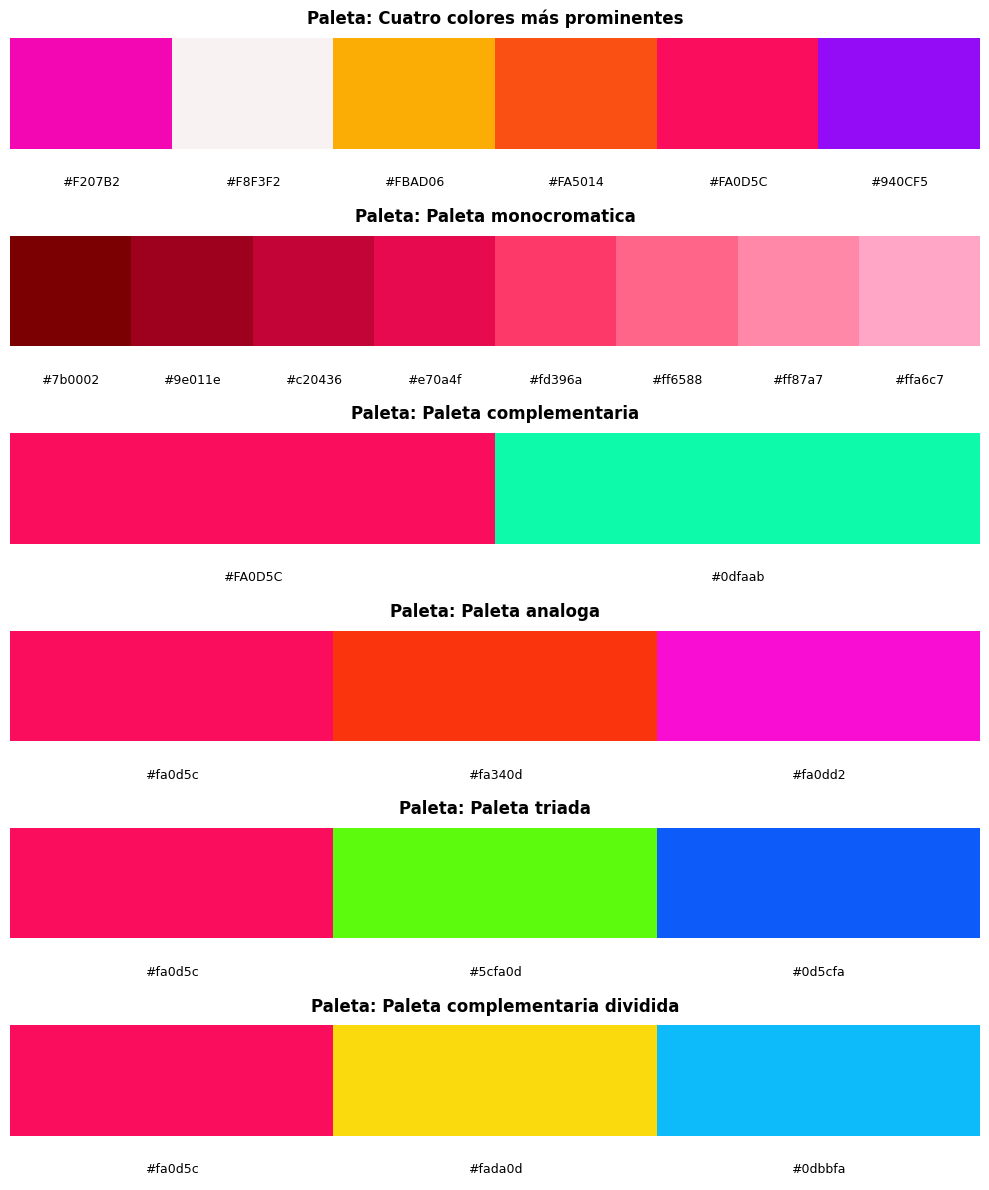

In [ ]:
# @title
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Definir múltiples paletas de colores en hexadecimal
logo = ['#F207B2', '#F8F3F2', '#FBAD06', '#FA5014', '#FA0D5C', '#940CF5']
monocromatico = ['#7b0002', '#9e011e', '#c20436', '#e70a4f', '#fd396a', '#ff6588', '#ff87a7', '#ffa6c7']
complementario = ['#FA0D5C', '#0dfaab']
analogo= ['#fa0d5c', '#fa340d', '#fa0dd2']
triada=['#fa0d5c', '#5cfa0d', '#0d5cfa']
complementarios_divididos=['#fa0d5c', '#fada0d', '#0dbbfa']

# Agrupar las paletas en un diccionario para gestión fácil
paletas = {
    'Cuatro colores más prominentes': logo,
    "Paleta monocromatica": monocromatico,
    "Paleta complementaria": complementario,
    "Paleta analoga": analogo,
    "Paleta triada": triada,
    "Paleta complementaria dividida": complementarios_divididos
}

def mostrar_paletas(paletas_dict):
    # Calcular dimensiones dinámicas basadas en la paleta más grande
    max_colores = max(len(colors) for colors in paletas_dict.values())
    num_paletas = len(paletas_dict)

    # Crear la figura y los ejes
    fig, axes = plt.subplots(num_paletas, 1, figsize=(10, 2 * num_paletas))

    # Asegurar que 'axes' sea iterable incluso si hay solo una paleta
    if num_paletas == 1:
        axes = [axes]

    # Recorrer cada paleta y su color
    for i, (nombre, colores) in enumerate(paletas_dict.items()):
        ax = axes[i]
        ax.set_xlim(0, len(colores))
        ax.set_ylim(0, 1)
        ax.axis('off')  # Ocultar ejes numéricos
        ax.set_title(f"Paleta: {nombre}", fontsize=12, fontweight='bold', pad=10)

        for j, color_hex in enumerate(colores):
            # Dibujar el rectángulo de color
            rect = patches.Rectangle((j, 0), 1, 1, linewidth=0, facecolor=color_hex)
            ax.add_patch(rect)

            # Agregar el código hexadecimal debajo del color
            ax.text(j + 0.5, -0.25, color_hex, ha='center', va='top', fontsize=9, color='black' if color_hex not in ['#F0F0F0', '#FFFFFF'] else 'black')

        # Ajustar el límite inferior para dejar espacio al texto
        ax.set_ylim(-0.4, 1)

    plt.tight_layout()
    plt.show()

# Ejecutar la función
mostrar_paletas(paletas)

## **Ventas totales en pesos por café**

**Descripción**: esta es una gráfica de barras que muestra las ventas totales en pesos por cada tipo de café.Primero agrupé todas las transacciones y luego se sumó el monto. Se puede ver que el Americano with Milk y el Latte son los que más venden, mientras que el Espresso es el que menos.

In [ ]:
ventas_cafe = df.groupby('coffee_name')['money'].sum().reset_index()

px.bar(ventas_cafe, x='coffee_name', y='money',
       color='coffee_name',
       color_discrete_sequence=monocromatico,
       title='Ventas Totales por Tipo de Café')

## **Distribución monto de ventas**

**Descripción**: Realicé un histogram que muestra cómo se distribuyen los montos de las ventas, separados por momento del día (Morning, Afternoon, Night). El rug plot de arriba permite ver cada transacción individual como una rayita. Se nota que los montos se concentran en valores muy específicos, lo cual tiene sentido porque cada café tiene su precio fijo. Hice uso de la paleta triada

In [ ]:
px.histogram(df, x='money',
            marginal='rug',
            color='Time_of_Day',
            hover_data=['coffee_name','Weekday'],
            color_discrete_sequence=triada,
            title='Distribución de Montos por Momento del Día')

## **Gráfica Scatter de ventas**

**Descripción**: Hice un Scatter plot donde cada punto es una venta. En el eje X está la hora y en el Y el monto. El color diferencia el tipo de café. Se puede ver que la mayoría de las ventas se concentran entre las 10am y las 2pm, que son las horas donde más gente compra café. Si pasas el mouse encima se ve el día y el momento del día y aquí usé la paleta del logo original

In [ ]:
*px.scatter(df, x='hour_of_day', y='money',
           color='coffee_name',
           hover_data=['Weekday','Time_of_Day'],
           opacity=0.5,
           color_discrete_sequence=logo,
           title='Hora del Día vs Monto por Tipo de Café')

## **Rango de precios por café**

**Descripción**: La siguiente gráfica es un box plot que muestra el rango de precios de cada tipo de café. Las cajas salen muy compactas porque cada producto tiene un precio fijo, entonces no hay mucha variación. Lo útil aquí es ver rápidamente cuál es el más caro (Latte y Hot Chocolate) y cuál el más barato (Espresso). En el hover se puede ver el día y la hora de cada venta.

In [ ]:
px.box(df, x='coffee_name', y='money',
       color='coffee_name',
       hover_data=['Weekday','hour_of_day'],
       color_discrete_sequence=monocromatico,
       title='Distribución de Precios por Tipo de Café')

## **Venta por día de la semana**

**Descripción**: Usé un strip chart porque es más fácil de visualizar ya que pone cada venta como un punto, organizado por día de la semana. El color separa mañana, tarde y noche. Se ve que entre semana hay más densidad de puntos que el fin de semana, especialmente los lunes y martes. También se nota que en la mañana es cuando más ventas hay.

In [ ]:
px.strip(df, x='Weekday', y='money',
         color='Time_of_Day',
         hover_data=['coffee_name'],
         color_discrete_sequence=triada,
         category_orders={'Weekday':['Mon','Tue','Wed','Thu','Fri','Sat','Sun']},
         title='Ventas por día de la semana')

## **Desglose de ventas**

**Descripción**: Esta gráfica es la más confusa pero es un sunburst que desglosa las ventas en tres niveles: primero por momento del día, luego por día de la semana y al final por tipo de café y se le puede dar click a cada sección para explorar más a detalle. El color va según el monto vendido. Se ve que la tarde es el momento con más ventas acumuladas.

In [ ]:
px.sunburst(df, path=['Time_of_Day','Weekday','coffee_name'],
            values='money', color='money',
            color_continuous_scale=logo,
            title='Desglose de ventas')

## **Ventas por tipo de café y día**

**Descripción** :Realicé un treemap que muestra las ventas agrupadas por tipo de café y después por el día. El tamaño de cada cuadro es proporcional a cuánto se vendió. De un vistazo se puede ver que el Americano with Milk domina bastante, seguido del Latte.

In [ ]:
px.treemap(df, path=['coffee_name','Weekday'],
           values='money', color='money',
           color_continuous_scale=monocromatico,
           title='Ventas por café y día')

## **Ventas mensuales por café**

**Descripción** : Realicé una gráfica de líneas(varias) con graphic objects que compara las ventas mensuales de tres cafés: Latte, Americano y Cappuccino. La línea del Cappuccino está punteada y en rosa para resaltarla. Se puede ver cómo varían las ventas a lo largo de los meses y si hay algún patrón estacional.

In [ ]:
ventas_mes = df.groupby(['Monthsort','coffee_name'])['money'].sum().reset_index()

fig8 = go.Figure()

fig8.add_trace(go.Scatter(x=ventas_mes[ventas_mes['coffee_name']=='Latte']['Monthsort'],
                          y=ventas_mes[ventas_mes['coffee_name']=='Latte']['money'], name='Latte'))
fig8.add_trace(go.Scatter(x=ventas_mes[ventas_mes['coffee_name']=='Americano']['Monthsort'],
                          y=ventas_mes[ventas_mes['coffee_name']=='Americano']['money'], name='Americano'))
fig8.add_trace(go.Scatter(x=ventas_mes[ventas_mes['coffee_name']=='Cappuccino']['Monthsort'],
                          y=ventas_mes[ventas_mes['coffee_name']=='Cappuccino']['money'], name='Cappuccino',
                          line=dict(color='#FA0D5C', width=4, dash='dot')))

fig8.update_layout(
    title='Ventas mensuales por café', xaxis_title='Mes', yaxis_title='Venta ($)')


## **Relación entre hora, monto y mes**

**Descripción** Esta es otra gráfica confusa pero necesaria. Es una gráfica de coordenadas paralelas que muestra tres variables numéricas al mismo tiempo: hora, monto y mes. Cada línea es una venta y el color va por monto, las más oscuras son las más caras. Sirve para ver si hay alguna relación entre la hora en que se compra y cuánto se gasta.

In [ ]:
px.parallel_coordinates(df,
    dimensions=['hour_of_day','money','Monthsort'],
    color='money',
    color_continuous_scale=monocromatico)

## **Tipo de café con día de la semana y su día**

**Descripción**: Esta es otra de las gráficas confusas en plotly que es un gráfico de categorías paralelas que conecta el tipo de café con el día de la semana y el momento del día. Se pueden seguir los flujos(*un poco complicado*) para ver por ejemplo que los Lattes se venden bastante parejo entre mañana y tarde, o que el Espresso casi no se vende en la noche.

In [ ]:
px.parallel_categories(df,
    dimensions=['coffee_name','Weekday','Time_of_Day'],
    color='money',
    color_continuous_scale=monocromatico)